# PyTorch Titanic Survival Classifier
### Building a Neural Network that predicts whether a Titanic passenger survived based on their information. 


In [2785]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score, 
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

import torch

In [2786]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/DeepLearning/Titanic-Dataset.csv.xls" )

X - Information about the passengers
y - whether they survived ( 0 - Did not survive, 1 - did survive) [ Binary Classification]

In [2787]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2788]:
df.shape

(891, 12)

In [2789]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [2790]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [2791]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [2792]:
y = df['Survived']

In [2793]:
y.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

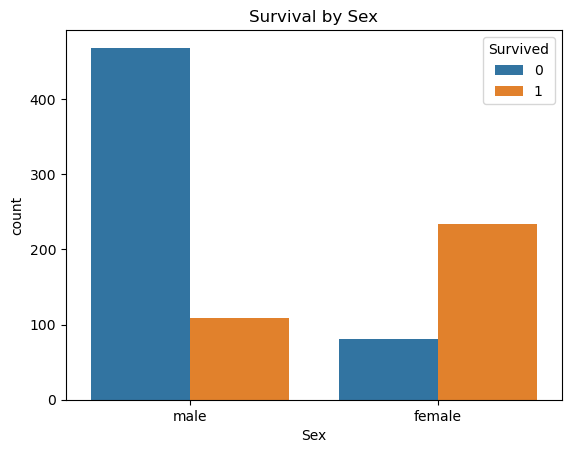

In [2794]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

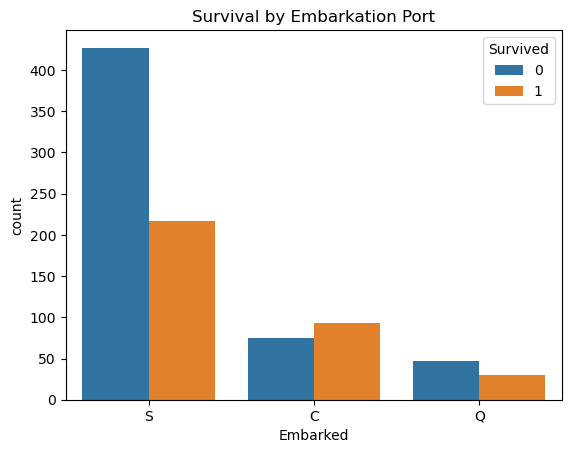

In [2795]:
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Survival by Embarkation Port")
plt.show()

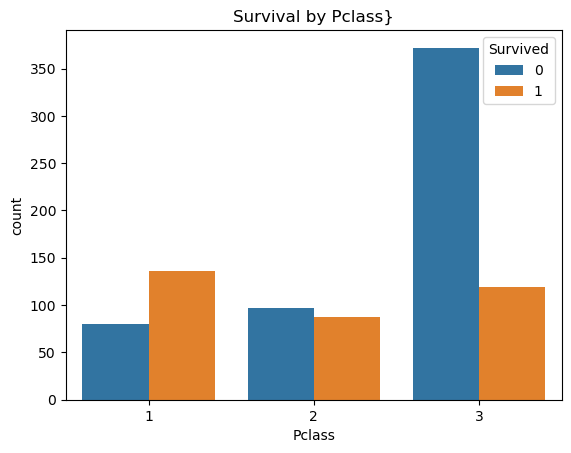

In [2796]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Pclass}")
plt.show()

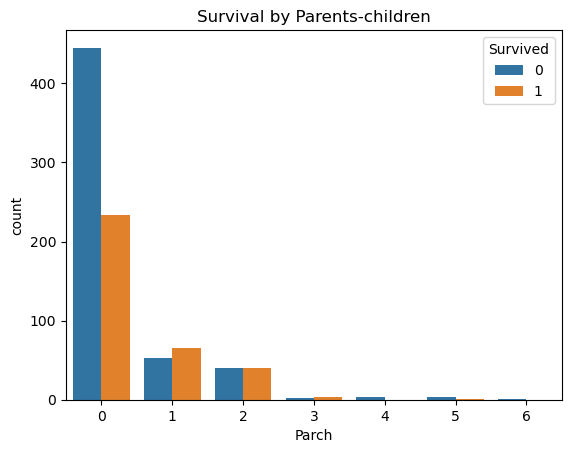

In [2797]:
sns.countplot(data=df, x="Parch", hue="Survived")
plt.title("Survival by Parents-children")
plt.show()

In [2798]:
# age is continuous, need grouupby
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


Text(0.5, 1.0, 'Age Distribution by Survival')

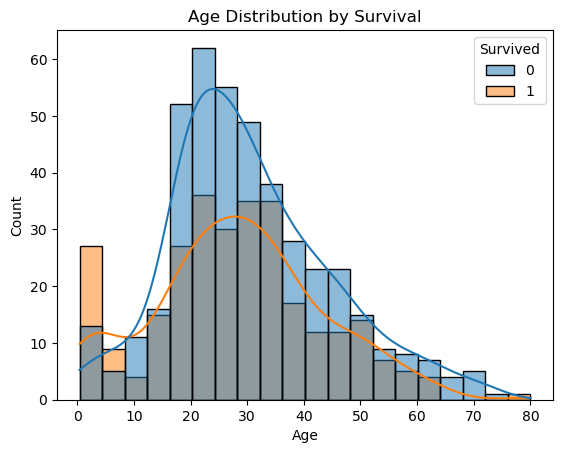

In [2799]:
sns.histplot(data=df, x = 'Age', hue = 'Survived', kde = True)
plt.title("Age Distribution by Survival")

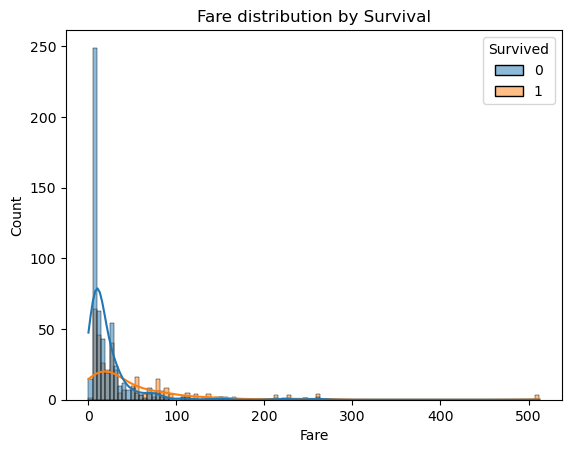

In [2800]:
# seems weird, edit later

sns.histplot(data=df, x= 'Fare', hue = 'Survived', kde = True)
plt.title("Fare distribution by Survival")
plt.show()

In [2801]:
# feature eng

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

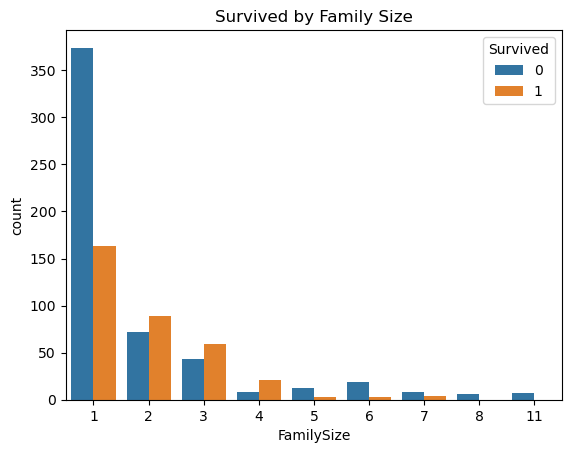

In [2802]:
sns.countplot(data=df, x='FamilySize', hue='Survived')
plt.title("Survived by Family Size")
plt.show()

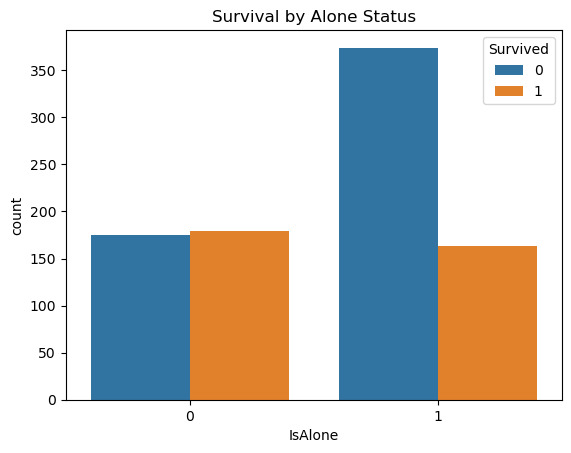

In [2803]:
sns.countplot(data=df, x='IsAlone', hue = 'Survived')
plt.title("Survival by Alone Status")
plt.show()

## Feature Set

In [2804]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone'
]

target = 'Survived'

X = df[features]
y = df[target]

In [2805]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


In [2806]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [2807]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train: ", X_train.shape)
print("Validate: ", X_val.shape)
print("Test: ", X_test.shape)


Train:  (623, 9)
Validate:  (134, 9)
Test:  (134, 9)


## Preprocessing Pipeline

In [2808]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone'
]

categorical_features = [
    'Sex',
    'Embarked'
]

In [2809]:
# Age contains missing values, fill missing values witht the median and standardize the variables
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Neural network trains more effectively when numerical inputs are on comparable scales

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# The two missing embarked values are replaced by the most frequent category

preprocesor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [2810]:
X_train_processed = preprocesor.fit_transform(X_train)
X_val_processed = preprocesor.transform(X_val)
X_test_processed = preprocesor.transform(X_test)

In [2811]:
print(type(X_train_processed))
print(X_train_processed.shape)
print(X_train_processed.dtype)

<class 'numpy.ndarray'>
(623, 12)
float64


In [2812]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [2813]:
# numpy to pytorch tensors

X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# for numeric, we use floating point

In [2814]:
print(X_train_tensor.shape)
print(X_train_tensor.dtype)

print(y_train_tensor.shape)
print(y_train_tensor.dtype)

torch.Size([623, 12])
torch.float32
torch.Size([623])
torch.float32


In [2815]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [2816]:
torch.manual_seed(42)
np.random.seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [2817]:
import torch.nn as nn

# number of inpute features
input_f = X_train_tensor.shape[1]
print(input_f)

12


In [2818]:
# Why do we add ReLU? - introduces nonlinear transformation

class TitanicModel(nn.Module):
    def __init__(self, input_f):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_f, 32),
            nn.ReLU(),
            # Adding a dropout feature - more resistent to overfitting
            # nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),
            # nn.Dropout(0.2)

            nn.Linear(16, 1)
        )
            

    def forward(self, x):
        return self.network(x)

In [2819]:
model = TitanicModel(input_f)
print(model)

TitanicModel(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [2820]:
criterion = nn.BCEWithLogitsLoss()

def evaluate_model(model, loader):
    model.eval()

    all_predictions = []
    all_probs = []
    all_targets = []

    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)

            loss = criterion(
                outputs.squeeze(1), y_batch
            )

            total_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze(1)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.numpy())
            all_predictions.extend(preds.numpy())
            all_targets.extend(y_batch.numpy())

    average_loss = total_loss / len(loader)

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    precision = precision_score(
        all_targets,
        all_predictions
    )

    recall = recall_score(
        all_targets,
        all_predictions
    )

    f1 = f1_score(
        all_targets,
        all_predictions
    )

    auc = roc_auc_score(
        all_targets,
        all_probs
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

In [2821]:
def train_model(model, optimizer, num_epochs = 20):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # training
        model.train()
        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs.squeeze(1), y_batch)

            loss.backward()

            optimizer.step() 

            total_train_loss += loss.item()

        average_train_loss = (total_train_loss / len(train_loader))

        # validation

        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(
                    outputs.squeeze(1),
                    y_batch
                )

                total_val_loss += loss.item()

        average_val_loss = (
            total_val_loss / len(val_loader)
        )

        train_losses.append(
            average_train_loss
        )

        val_losses.append(
            average_val_loss
        )

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f}"
        )

    return train_losses, val_losses
    

## Trial 1: Linear + SGD + No Regularization

In [2822]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

In [2823]:
input_features = X_train_tensor.shape[1]
model_1 = LinearModel(input_features)

optimizer_1 = torch.optim.SGD(
    model_1.parameters(),
    lr = 0.01
)

In [2824]:
train_losses_1, val_losses_1 = train_model(
    model_1,
    optimizer_1,
    num_epochs = 20
)

Epoch 1/20 | Train Loss: 0.6261 | Val Loss: 0.6344
Epoch 2/20 | Train Loss: 0.6112 | Val Loss: 0.6203
Epoch 3/20 | Train Loss: 0.6013 | Val Loss: 0.6082
Epoch 4/20 | Train Loss: 0.5888 | Val Loss: 0.5972
Epoch 5/20 | Train Loss: 0.5757 | Val Loss: 0.5874
Epoch 6/20 | Train Loss: 0.5694 | Val Loss: 0.5790
Epoch 7/20 | Train Loss: 0.5576 | Val Loss: 0.5712
Epoch 8/20 | Train Loss: 0.5564 | Val Loss: 0.5644
Epoch 9/20 | Train Loss: 0.5520 | Val Loss: 0.5581
Epoch 10/20 | Train Loss: 0.5453 | Val Loss: 0.5526
Epoch 11/20 | Train Loss: 0.5395 | Val Loss: 0.5472
Epoch 12/20 | Train Loss: 0.5358 | Val Loss: 0.5424
Epoch 13/20 | Train Loss: 0.5302 | Val Loss: 0.5377
Epoch 14/20 | Train Loss: 0.5225 | Val Loss: 0.5335
Epoch 15/20 | Train Loss: 0.5226 | Val Loss: 0.5294
Epoch 16/20 | Train Loss: 0.5198 | Val Loss: 0.5256
Epoch 17/20 | Train Loss: 0.5125 | Val Loss: 0.5220
Epoch 18/20 | Train Loss: 0.5141 | Val Loss: 0.5189
Epoch 19/20 | Train Loss: 0.5066 | Val Loss: 0.5155
Epoch 20/20 | Train L

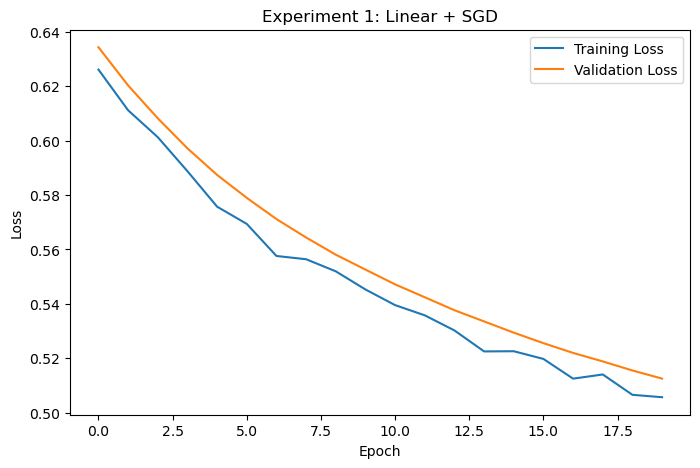

In [2825]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_1,
    label="Training Loss"
)

plt.plot(
    val_losses_1,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1: Linear + SGD")

plt.legend()
plt.show()

In [2826]:
results_1 = evaluate_model(model_1, val_loader)
results_1

{'loss': 0.5125341892242432,
 'accuracy': 0.7611940298507462,
 'precision': 0.8333333333333334,
 'recall': 0.4807692307692308,
 'f1': 0.6097560975609756,
 'auc': np.float64(0.875)}

## Trial 2: Hidden Layers + ReLU + SGD

In [2827]:
class TitanicMLP(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [2828]:
model_2 = TitanicMLP(input_features)

optimizer_2 = torch.optim.SGD(
    model_2.parameters(),
    lr=0.01,
)

train_losses_2, val_losses_2 = train_model(
    model_2,
    optimizer_2,
    num_epochs=20
)

Epoch 1/20 | Train Loss: 0.7101 | Val Loss: 0.7005
Epoch 2/20 | Train Loss: 0.6993 | Val Loss: 0.6915
Epoch 3/20 | Train Loss: 0.6897 | Val Loss: 0.6840
Epoch 4/20 | Train Loss: 0.6817 | Val Loss: 0.6777
Epoch 5/20 | Train Loss: 0.6747 | Val Loss: 0.6723
Epoch 6/20 | Train Loss: 0.6685 | Val Loss: 0.6676
Epoch 7/20 | Train Loss: 0.6628 | Val Loss: 0.6634
Epoch 8/20 | Train Loss: 0.6588 | Val Loss: 0.6598
Epoch 9/20 | Train Loss: 0.6552 | Val Loss: 0.6565
Epoch 10/20 | Train Loss: 0.6521 | Val Loss: 0.6535
Epoch 11/20 | Train Loss: 0.6455 | Val Loss: 0.6505
Epoch 12/20 | Train Loss: 0.6433 | Val Loss: 0.6477
Epoch 13/20 | Train Loss: 0.6387 | Val Loss: 0.6450
Epoch 14/20 | Train Loss: 0.6376 | Val Loss: 0.6424
Epoch 15/20 | Train Loss: 0.6317 | Val Loss: 0.6396
Epoch 16/20 | Train Loss: 0.6319 | Val Loss: 0.6370
Epoch 17/20 | Train Loss: 0.6257 | Val Loss: 0.6343
Epoch 18/20 | Train Loss: 0.6204 | Val Loss: 0.6315
Epoch 19/20 | Train Loss: 0.6154 | Val Loss: 0.6288
Epoch 20/20 | Train L

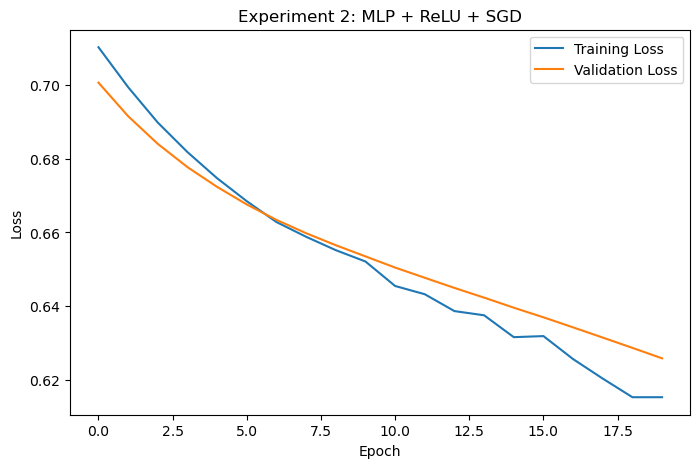

In [2829]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_2,
    label="Training Loss"
)

plt.plot(
    val_losses_2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2: MLP + ReLU + SGD")

plt.legend()
plt.show()

In [2830]:
results_2 = evaluate_model(model_2, val_loader)
results_2

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'loss': 0.6259180784225464,
 'accuracy': 0.6119402985074627,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'auc': np.float64(0.8562382739212007)}

## Trial 3: MLP + ReLU + SGD Momentum

In [2831]:
model_3 = TitanicMLP(
    input_features
)

optimizer_3 = torch.optim.SGD(
    model_3.parameters(),
    lr = 0.01,
    momentum = 0.9
)

train_losses_3, val_losses_3 = train_model(
    model_3, 
    optimizer_3, 
    num_epochs=20
)

Epoch 1/20 | Train Loss: 0.6861 | Val Loss: 0.6764
Epoch 2/20 | Train Loss: 0.6686 | Val Loss: 0.6659
Epoch 3/20 | Train Loss: 0.6552 | Val Loss: 0.6558
Epoch 4/20 | Train Loss: 0.6440 | Val Loss: 0.6408
Epoch 5/20 | Train Loss: 0.6238 | Val Loss: 0.6166
Epoch 6/20 | Train Loss: 0.6016 | Val Loss: 0.5782
Epoch 7/20 | Train Loss: 0.5538 | Val Loss: 0.5324
Epoch 8/20 | Train Loss: 0.5100 | Val Loss: 0.4812
Epoch 9/20 | Train Loss: 0.4726 | Val Loss: 0.4430
Epoch 10/20 | Train Loss: 0.4527 | Val Loss: 0.4223
Epoch 11/20 | Train Loss: 0.4460 | Val Loss: 0.4041
Epoch 12/20 | Train Loss: 0.4350 | Val Loss: 0.4027
Epoch 13/20 | Train Loss: 0.4318 | Val Loss: 0.3964
Epoch 14/20 | Train Loss: 0.4365 | Val Loss: 0.3941
Epoch 15/20 | Train Loss: 0.4238 | Val Loss: 0.3915
Epoch 16/20 | Train Loss: 0.4235 | Val Loss: 0.3895
Epoch 17/20 | Train Loss: 0.4237 | Val Loss: 0.3887
Epoch 18/20 | Train Loss: 0.4217 | Val Loss: 0.3892
Epoch 19/20 | Train Loss: 0.4099 | Val Loss: 0.3883
Epoch 20/20 | Train L

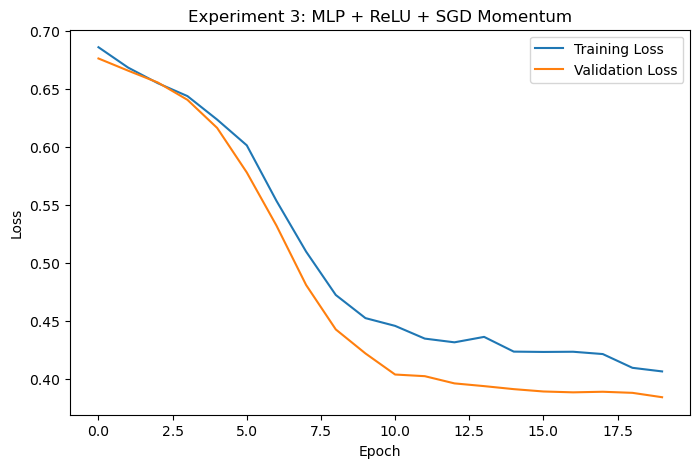

In [2832]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_3,
    label="Training Loss"
)

plt.plot(
    val_losses_3,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 3: MLP + ReLU + SGD Momentum")

plt.legend()
plt.show()

In [2833]:
results_3 = evaluate_model(model_3, val_loader)
results_3

{'loss': 0.3845287561416626,
 'accuracy': 0.8283582089552238,
 'precision': 0.8222222222222222,
 'recall': 0.7115384615384616,
 'f1': 0.7628865979381443,
 'auc': np.float64(0.9104127579737336)}

## Experiment 4 - MLP + ReLU + Adam

Epoch 1/20 | Train Loss: 0.6811 | Val Loss: 0.6726
Epoch 2/20 | Train Loss: 0.6772 | Val Loss: 0.6683
Epoch 3/20 | Train Loss: 0.6726 | Val Loss: 0.6641
Epoch 4/20 | Train Loss: 0.6685 | Val Loss: 0.6598
Epoch 5/20 | Train Loss: 0.6643 | Val Loss: 0.6554
Epoch 6/20 | Train Loss: 0.6604 | Val Loss: 0.6511
Epoch 7/20 | Train Loss: 0.6553 | Val Loss: 0.6467
Epoch 8/20 | Train Loss: 0.6518 | Val Loss: 0.6422
Epoch 9/20 | Train Loss: 0.6475 | Val Loss: 0.6375
Epoch 10/20 | Train Loss: 0.6424 | Val Loss: 0.6330
Epoch 11/20 | Train Loss: 0.6376 | Val Loss: 0.6282
Epoch 12/20 | Train Loss: 0.6323 | Val Loss: 0.6233
Epoch 13/20 | Train Loss: 0.6278 | Val Loss: 0.6184
Epoch 14/20 | Train Loss: 0.6222 | Val Loss: 0.6132
Epoch 15/20 | Train Loss: 0.6174 | Val Loss: 0.6081
Epoch 16/20 | Train Loss: 0.6132 | Val Loss: 0.6028
Epoch 17/20 | Train Loss: 0.6065 | Val Loss: 0.5976
Epoch 18/20 | Train Loss: 0.6016 | Val Loss: 0.5921
Epoch 19/20 | Train Loss: 0.5947 | Val Loss: 0.5869
Epoch 20/20 | Train L

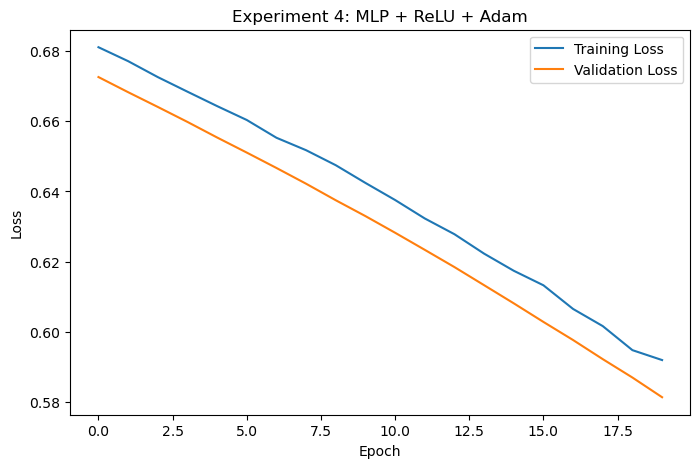

In [2834]:
model_4 = TitanicMLP(input_features)

Optimizer_4 = torch.optim.Adam(model_4.parameters(), lr = 0.0001)

train_losses_4, val_losses_4, = train_model(
    model_4,
    Optimizer_4,
    num_epochs=20
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_4,
    label="Training Loss"
)

plt.plot(
    val_losses_4,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 4: MLP + ReLU + Adam")

plt.legend()
plt.show()

In [2835]:
results_4 = evaluate_model(
    model_4,
    val_loader
)

results_4

{'loss': 0.581279456615448,
 'accuracy': 0.7835820895522388,
 'precision': 0.96,
 'recall': 0.46153846153846156,
 'f1': 0.6233766233766234,
 'auc': np.float64(0.8989212007504691)}

## Trial 5 - Adam + Weight_decay

Epoch 1/20 | Train Loss: 0.6885 | Val Loss: 0.6707
Epoch 2/20 | Train Loss: 0.6563 | Val Loss: 0.6357
Epoch 3/20 | Train Loss: 0.6149 | Val Loss: 0.5971
Epoch 4/20 | Train Loss: 0.5773 | Val Loss: 0.5576
Epoch 5/20 | Train Loss: 0.5477 | Val Loss: 0.5263
Epoch 6/20 | Train Loss: 0.5109 | Val Loss: 0.4966
Epoch 7/20 | Train Loss: 0.4902 | Val Loss: 0.4744
Epoch 8/20 | Train Loss: 0.4709 | Val Loss: 0.4540
Epoch 9/20 | Train Loss: 0.4565 | Val Loss: 0.4405
Epoch 10/20 | Train Loss: 0.4472 | Val Loss: 0.4313
Epoch 11/20 | Train Loss: 0.4393 | Val Loss: 0.4247
Epoch 12/20 | Train Loss: 0.4311 | Val Loss: 0.4164
Epoch 13/20 | Train Loss: 0.4296 | Val Loss: 0.4120
Epoch 14/20 | Train Loss: 0.4316 | Val Loss: 0.4103
Epoch 15/20 | Train Loss: 0.4269 | Val Loss: 0.4040
Epoch 16/20 | Train Loss: 0.4272 | Val Loss: 0.4011
Epoch 17/20 | Train Loss: 0.4209 | Val Loss: 0.3986
Epoch 18/20 | Train Loss: 0.4160 | Val Loss: 0.3968
Epoch 19/20 | Train Loss: 0.4186 | Val Loss: 0.3949
Epoch 20/20 | Train L

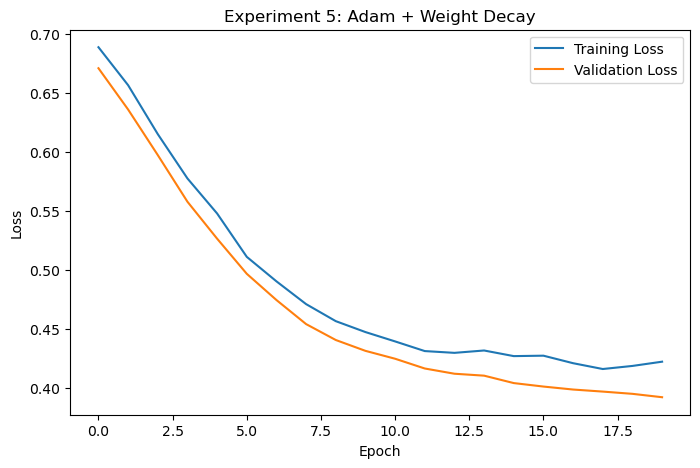

In [2836]:
model_5 = TitanicMLP(input_features)

optimizer_5 = torch.optim.Adam(
    model_5.parameters(),
    lr = 0.001,
    weight_decay = 0.0001
)

train_losses_5, val_losses_5 = train_model(
    model_5,
    optimizer_5,
    num_epochs=20
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_5,
    label="Training Loss"
)

plt.plot(
    val_losses_5,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 5: Adam + Weight Decay")

plt.legend()
plt.show()

In [2837]:
results_5 = evaluate_model(model_5, val_loader)
results_5

{'loss': 0.3920634925365448,
 'accuracy': 0.835820895522388,
 'precision': 0.7884615384615384,
 'recall': 0.7884615384615384,
 'f1': 0.7884615384615384,
 'auc': np.float64(0.9127579737335835)}

## Trial 6: Adam + Weight Decay + Dropout

In [2838]:
class TitanicMLPDropout(nn.Module):
    def __init__(
            self,
            input_features,
            dropout_rate = 0.3
    ):
        
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)


In [2839]:
model_6 = TitanicMLPDropout(
    input_features,
    dropout_rate=0.3
)

Optimizer_6 = torch.optim.Adam(
    model_6.parameters(),
    lr = 0.001,
    weight_decay = 0.0001
)

train_losses_6, val_losses_6 = train_model(
    model_6,
    Optimizer_6,
    num_epochs=20
)

Epoch 1/20 | Train Loss: 0.6945 | Val Loss: 0.6781
Epoch 2/20 | Train Loss: 0.6602 | Val Loss: 0.6509
Epoch 3/20 | Train Loss: 0.6408 | Val Loss: 0.6211
Epoch 4/20 | Train Loss: 0.6016 | Val Loss: 0.5954
Epoch 5/20 | Train Loss: 0.5829 | Val Loss: 0.5704
Epoch 6/20 | Train Loss: 0.5537 | Val Loss: 0.5476
Epoch 7/20 | Train Loss: 0.5420 | Val Loss: 0.5262
Epoch 8/20 | Train Loss: 0.5184 | Val Loss: 0.5046
Epoch 9/20 | Train Loss: 0.5208 | Val Loss: 0.4819
Epoch 10/20 | Train Loss: 0.4866 | Val Loss: 0.4626
Epoch 11/20 | Train Loss: 0.4795 | Val Loss: 0.4480
Epoch 12/20 | Train Loss: 0.4769 | Val Loss: 0.4371
Epoch 13/20 | Train Loss: 0.4588 | Val Loss: 0.4281
Epoch 14/20 | Train Loss: 0.4445 | Val Loss: 0.4195
Epoch 15/20 | Train Loss: 0.4676 | Val Loss: 0.4165
Epoch 16/20 | Train Loss: 0.4588 | Val Loss: 0.4115
Epoch 17/20 | Train Loss: 0.4590 | Val Loss: 0.4078
Epoch 18/20 | Train Loss: 0.4478 | Val Loss: 0.4067
Epoch 19/20 | Train Loss: 0.4544 | Val Loss: 0.4065
Epoch 20/20 | Train L

In [2840]:
results_6 = evaluate_model(
    model_6,
    val_loader
)

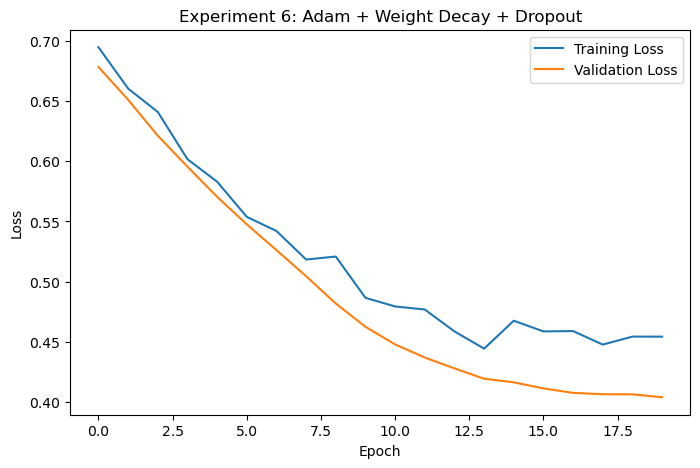

In [2841]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_6,
    label="Training Loss"
)

plt.plot(
    val_losses_6,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 6: Adam + Weight Decay + Dropout")

plt.legend()
plt.show()

In [2842]:
results_6 = evaluate_model(
    model_6,
    val_loader
)

results_6

{'loss': 0.40416626930236815,
 'accuracy': 0.8582089552238806,
 'precision': 0.851063829787234,
 'recall': 0.7692307692307693,
 'f1': 0.8080808080808081,
 'auc': np.float64(0.9090056285178237)}

In [2843]:
results = pd.DataFrame({

    "Experiment": [
        "1. Linear + SGD",
        "2. MLP + ReLU + SGD",
        "3. MLP + ReLU + SGD Momentum",
        "4. MLP + ReLU + Adam",
        "5. Adam + Weight Decay",
        "6. Adam + Weight Decay + Dropout"
    ],

    "Validation Loss": [
        results_1["loss"],
        results_2["loss"],
        results_3["loss"],
        results_4["loss"],
        results_5["loss"],
        results_6["loss"]
    ],

    "Accuracy": [
        results_1["accuracy"],
        results_2["accuracy"],
        results_3["accuracy"],
        results_4["accuracy"],
        results_5["accuracy"],
        results_6["accuracy"]
    ],

    "Precision": [
        results_1["precision"],
        results_2["precision"],
        results_3["precision"],
        results_4["precision"],
        results_5["precision"],
        results_6["precision"]
    ],

    "Recall": [
        results_1["recall"],
        results_2["recall"],
        results_3["recall"],
        results_4["recall"],
        results_5["recall"],
        results_6["recall"]
    ],

    "F1": [
        results_1["f1"],
        results_2["f1"],
        results_3["f1"],
        results_4["f1"],
        results_5["f1"],
        results_6["f1"]
    ],

    "ROC-AUC": [
        results_1["auc"],
        results_2["auc"],
        results_3["auc"],
        results_4["auc"],
        results_5["auc"],
        results_6["auc"]
    ]
})

results

,Experiment,Validation Loss,Accuracy,Precision,Recall,F1,ROC-AUC
0,1. Linear + SGD,0.512534,0.761194,0.833333,0.480769,0.609756,0.875000
1,2. MLP + ReLU + SGD,0.625918,0.611940,0.000000,0.000000,0.000000,0.856238
2,3. MLP + ReLU + SGD Momentum,0.384529,0.828358,0.822222,0.711538,0.762887,0.910413
3,4. MLP + ReLU + Adam,0.581279,0.783582,0.960000,0.461538,0.623377,0.898921
4,5. Adam + Weight Decay,0.392063,0.835821,0.788462,0.788462,0.788462,0.912758
5,6. Adam + Weight Decay + Dropout,0.404166,0.858209,0.851064,0.769231,0.808081,0.909006


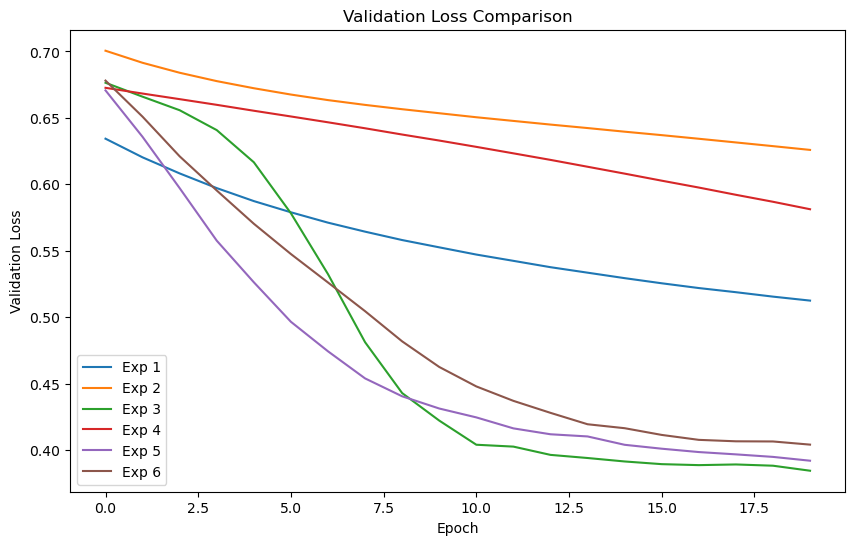

In [2844]:
plt.figure(figsize=(10, 6))

plt.plot(
    val_losses_1,
    label="Exp 1"
)

plt.plot(
    val_losses_2,
    label="Exp 2"
)

plt.plot(
    val_losses_3,
    label="Exp 3"
)

plt.plot(
    val_losses_4,
    label="Exp 4"
)

plt.plot(
    val_losses_5,
    label="Exp 5"
)

plt.plot(
    val_losses_6,
    label="Exp 6"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss Comparison"
)

plt.legend()

plt.show()

## Final Model Chosen: Model 6

In [2845]:
def train_final_model(model, optimizer, num_epochs=100, patience=10):
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_state = None

    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        # Training

        model.train()

        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(
                outputs.squeeze(1),
                y_batch
            )
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        average_train_loss = (total_train_loss / len(train_loader))

        # validation

        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)

                loss = criterion(outputs.squeeze(1), y_batch)
                total_val_loss += loss.item()

        average_val_loss = (total_val_loss / len(val_loader))

        train_losses.append(average_train_loss)
        val_losses.append(average_val_loss)

        # save best model

        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss

            best_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else: 
            epochs_without_improvement += 1



        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f}"
        )

        # Early stopping
    
        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch {epoch + 1}"
            )

            break

    # Restore best model

    model.load_state_dict(best_state)

    print(
        f"\nBest Validation Loss: "
        f"{best_val_loss:.4f}"
    )

    return train_losses, val_losses

In [2846]:
final_model = TitanicMLPDropout(
    input_features,
    dropout_rate=0.3
)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr = 0.001,
    weight_decay=0.0001
)

final_train_losses, final_val_losses = train_final_model(
    final_model,
    final_optimizer,
    num_epochs=100,
    patience = 10
)

Epoch 1/100 | Train Loss: 0.6766 | Val Loss: 0.6732
Epoch 2/100 | Train Loss: 0.6651 | Val Loss: 0.6645
Epoch 3/100 | Train Loss: 0.6540 | Val Loss: 0.6491
Epoch 4/100 | Train Loss: 0.6323 | Val Loss: 0.6259
Epoch 5/100 | Train Loss: 0.6125 | Val Loss: 0.5969
Epoch 6/100 | Train Loss: 0.5824 | Val Loss: 0.5640
Epoch 7/100 | Train Loss: 0.5666 | Val Loss: 0.5310
Epoch 8/100 | Train Loss: 0.5297 | Val Loss: 0.5006
Epoch 9/100 | Train Loss: 0.5124 | Val Loss: 0.4748
Epoch 10/100 | Train Loss: 0.5161 | Val Loss: 0.4576
Epoch 11/100 | Train Loss: 0.4710 | Val Loss: 0.4394
Epoch 12/100 | Train Loss: 0.4627 | Val Loss: 0.4274
Epoch 13/100 | Train Loss: 0.4653 | Val Loss: 0.4188
Epoch 14/100 | Train Loss: 0.4691 | Val Loss: 0.4142
Epoch 15/100 | Train Loss: 0.4617 | Val Loss: 0.4094
Epoch 16/100 | Train Loss: 0.4565 | Val Loss: 0.4096
Epoch 17/100 | Train Loss: 0.4570 | Val Loss: 0.4064
Epoch 18/100 | Train Loss: 0.4364 | Val Loss: 0.3997
Epoch 19/100 | Train Loss: 0.4619 | Val Loss: 0.3989
Ep

In [2847]:
final_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = final_model(X_batch)

        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= 0.5).float()
        
        all_preds.extend(preds.numpy())
        all_targets.extend(y_batch.numpy())

print(classification_report(all_targets, all_preds, target_names= ["Did Not Survive", "Survived"]))


                 precision    recall  f1-score   support

Did Not Survive       0.84      0.91      0.88        82
       Survived       0.84      0.73      0.78        52

       accuracy                           0.84       134
      macro avg       0.84      0.82      0.83       134
   weighted avg       0.84      0.84      0.84       134



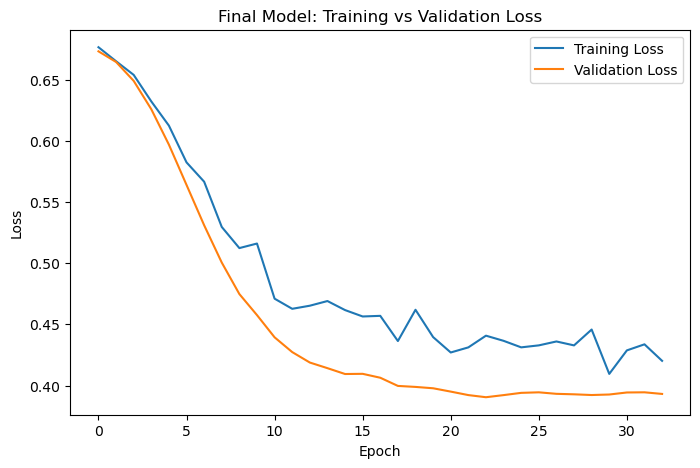

In [2848]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_train_losses,
    label="Training Loss"
)

plt.plot(
    final_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model: Training vs Validation Loss")
plt.legend()

plt.show()

### Prediction Function

In [2849]:
def predict_survival(passenger):

    
    pass_df = pd.DataFrame([passenger])

    # preprocessing used during training
    pass_processed = preprocesor.transform(pass_df)

    # convert to pytorch tensor
    pass_tensor = torch.tensor(
        pass_processed,
        dtype=torch.float32
    )

    # make pred
    final_model.eval()
    
    with torch.no_grad():
        output = final_model(pass_tensor)
        prob = torch.sigmoid(output).item()

    # Convert prob to class
    pred = "Survived" if prob >= 0.5 else "Did Not Survive"

    print(f"Survival Probability: {prob:.2%}")
    print(f"Prediction: {pred}")

In [2850]:
passenger = {
    "Pclass": 3,
    "Age": 22,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 7.25,
    "FamilySize": 2,
    "IsAlone": 0,
    "Sex": "male",
    "Embarked": "S"
}

predict_survival(passenger)

Survival Probability: 14.57%
Prediction: Did Not Survive
